In [1]:
import numpy as np
import sys
from langchain.vectorstores import Chroma
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.schema import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
sys.path.append('../../')
from src.models.vectorDBbuild import VectorDBBuilder
from src.models.lightfm import LightFMTrainer
from src.models.hybrid_retrieval import RetrievalEngine
from src.models.llm import LLMReranker
# from src.models.newUser import NewUserRetriever

def run_full_pipeline(data, test_user_ids=None, debug=False):
    print("Training LightFM model")
    lightfm_model = LightFMTrainer()
    lightfm_model.fit_and_train(data, learning_rate=0.01, epochs=50)
    all_recommendations = lightfm_model.get_top_k(k=50)
    
    df_data = []
    for user_id, recs in all_recommendations.items():
        df_data.append({
            'user_id': user_id,
            'recommendations': recs
        })
    
    df = pd.DataFrame(df_data)
    
    # for user_id, recs in all_recommendations.items():
    #     for rec in recs:
    #         # Enhance with additional metadata if available
    #         enhanced_rec = {
    #             'user_id': user_id,
    #             'iid': rec['iid'],
    #             'title': rec.get('title', ''),
    #             'categories': rec.get('categories', []),
    #             'description': rec.get('description', ''),
    #             'cf_score': rec['score']
    #         }
    #         df_data.append(enhanced_rec)
    
    # df = pd.DataFrame(df_data)
    
    # build vector DB
    print("Building vector database...")
    vector_builder = VectorDBBuilder()
    embedder = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
    df = vector_builder.preprocess_for_augmentation(df)
    items_df = vector_builder.extract_items_metadata(df)
    chroma_db = vector_builder.build_from_dataframe(items_df)
    
    # set up retrieval engine 
    retriever = RetrievalEngine(None, embedder)
    retriever.chroma_db = chroma_db
    llm_reranker = LLMReranker()
    
    return {
        'df': df,
        'chroma_db': chroma_db,
        'retriever': retriever,
        # 'llm_reranker': llm_reranker,
        # 'top_k_results': top_k_results,
        'lightfm_model': lightfm_model
    }

/Users/vynguyen/anaconda3/envs/thesis/lib/python3.11/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


In [2]:
def get_recommendations_for_user(pipeline_objects, user_id, query, debug=False):
    df = pipeline_objects['df']
    chroma_db = pipeline_objects['chroma_db']
    retriever = pipeline_objects['retriever']
    llm_reranker = pipeline_objects['llm_reranker']
    #top_k_results = pipeline_objects['top_k_results']
    
    user_type = "existing" if check_user_type(user_id, df) else "new"
    
    if user_type == "existing":
        user_recs = df[df['user_id'] == user_id]['recommendations'].iloc[0]
        # user_recs = top_k_results[user_id]
        
        augmented = []
        for rec in user_recs:
            # get additional context from vector database
            try:
                chunks = chroma_db.similarity_search(
                    query=rec.get('combined_text', rec.get('title', '')),
                    k=3,
                    filter={"iid": rec['iid']}
                )
                augmented_text = f"{rec.get('combined_text', '')}\nRelated Context:\n{' '.join([chunk.page_content for chunk in chunks])}"
            except:
                # fallback if vector search fails
                augmented_text = rec.get('combined_text', '')
            
            augmented.append({
                **rec,
                "combined_text": rec.get('combined_text', ''),
                "augmented_text": augmented_text
            })
        
        # if debug:
        #     print("=== After Augmentation ===")
        #     print(f"Found {len(augmented)} items")
        #     for i, item in enumerate(augmented[:3], 1):
        #         print(f"{i}. {item['title']} - {item.get('combined_text', '')[:100]}...")
        
        # Hybrid retrieval
        scored = retriever.hybrid_retrieve(augmented, query)
        
        if debug:
            print("\n=== After Hybrid Retrieval ===")
            print(f"Top 10 items by hybrid score:")
            for i, item in enumerate(sorted(scored, key=lambda x: x.get('hybrid_score', 0), reverse=True)[:10], 1):
                print(f"{i}. {item['title']} (Hybrid: {item.get('hybrid_score', 0):.3f})")
                print(f"   Categories: {''.join(item.get('categories', []))}")
                description = item.get('description', '')
                if description and isinstance(description, str):
                    print(f"   Description: {description[:150]}...")
                # print(f"   Description: {item.get('description', '')[:150]}...\n")
        
        # MMR Diversification
        diversified = retriever.mmr_diversify(scored, query)
        
        if debug:
            print("\n=== After MMR Diversification ===")
            print(f"Top 10 diversified items:")
            for i, item in enumerate(diversified[:10], 1):
                print(f"{i}. {item['title']} (Hybrid: {item.get('hybrid_score', 0):.3f}, MMR: {item.get('mmr_score', 0):.3f})")
                print(f"   Categories: {''.join(item.get('categories', []))}")
                # print(f"   Description: {item.get('description', '')[:150]}...\n")
                description = item.get('description', '')
                if description and isinstance(description, str):
                    print(f"   Description: {description[:150]}...")
                print()
                
        LLM Reranking
        llm_result = llm_reranker.rerank(diversified, query, user_id, user_type)
        
        if debug:
            print("\n=== Final LLM-Ranked Results ===")
            print(f"Top 10 final recommendations:")
            for i, item in enumerate(llm_result['parsed_items'][:10], 1):
                print(f"{i}. {item['title']} (ID: {item['iid']})")
                if 'hybrid_score' in item:
                    print(f"   Hybrid Score: {item['hybrid_score']:.3f}")
                if 'mmr_score' in item:
                    print(f"   MMR Score: {item['mmr_score']:.3f}")
                print() 
        
        return diversified[:10]
        # llm_result['parsed_items'][:10]

In [3]:
def check_user_type(user_id, df):
    return user_id in df['user_id'].values

In [4]:
import pickle
import os
import traceback
import json
from langchain.vectorstores import Chroma
from langchain.embeddings import HuggingFaceEmbeddings

def save_trained_pipeline_simple(pipeline_objects, save_dir="saved_pipeline"):
    os.makedirs(save_dir, exist_ok=True)
    
    # extract and save only the recommendations DataFrame
    df = pipeline_objects['df']

    df_clean = df.copy()
    
    # convert recommendations to JSON strings
    if 'recommendations' in df_clean.columns:
        df_clean['recommendations_json'] = df_clean['recommendations'].apply(json.dumps)
        df_clean = df_clean.drop('recommendations', axis=1)
    
    df_clean.to_csv(f"{save_dir}/recommendations.csv", index=False)
    
    # also save as pickle for easier loading
    df.to_pickle(f"{save_dir}/recommendations.pkl")
    # df.to_csv(f"{save_dir}/recommendations.csv", index=False)
    
    # Save any additional metadata needed
    metadata = {
        'total_users': len(df),
        'columns': list(df.columns)
    }
    
    with open(f"{save_dir}/metadata.pkl", 'wb') as f:
        pickle.dump(metadata, f)
    
    print(f"Pipeline data saved to {save_dir}/")
    print(f"- Recommendations: {len(df)} users")
    print(f"- Files: recommendations.csv, recommendations.pkl")

def load_trained_pipeline_simple(save_dir="saved_pipeline", chroma_db_path="./chroma_db"):
    try:
        # Load recommendations
        if os.path.exists(f"{save_dir}/recommendations.pkl"):
            print("Loading from pickle file...")
            df = pd.read_pickle(f"{save_dir}/recommendations.pkl")
        else:
            print("Loading from CSV file...")
            df = pd.read_csv(f"{save_dir}/recommendations.csv")
            
            # Handle different CSV formats
            if 'recommendations_json' in df.columns:
                # Convert from JSON strings
                df['recommendations'] = df['recommendations_json'].apply(json.loads)
                df = df.drop('recommendations_json', axis=1)
            elif 'recommendations' in df.columns:
                # Try to parse as JSON first, then fall back to ast.literal_eval
                try:
                    df['recommendations'] = df['recommendations'].apply(json.loads)
                except:
                    try:
                        import ast
                        df['recommendations'] = df['recommendations'].apply(ast.literal_eval)
                    except Exception as e:
                        print(f"Warning: Could not parse recommendations column: {e}")
                        print("Sample of problematic data:")
                        print(df['recommendations'].iloc[0][:500] if len(df) > 0 else "No data")
                        return None
        
        print(f"Loaded DataFrame shape: {df.shape}")
        print(f"Columns: {df.columns.tolist()}")
        
        if len(df) > 0:
            print(f"First user recommendations type: {type(df['recommendations'].iloc[0])}")
            if hasattr(df['recommendations'].iloc[0], '__len__'):
                print(f"First user has {len(df['recommendations'].iloc[0])} recommendations")
                
        # Load ChromaDB
        embedder = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
        if not os.path.exists(chroma_db_path):
            print(f"ChromaDB path not found: {chroma_db_path}")
            print("Please check the path or retrain the pipeline.")
            return None
            
        chroma_db = Chroma(persist_directory=chroma_db_path, embedding_function=embedder)
        
        # Recreate retriever
        from src.models.hybrid_retrieval import RetrievalEngine
        retriever = RetrievalEngine(None, embedder)
        retriever.chroma_db = chroma_db
        
        pipeline_objects = {
            'df': df,
            'chroma_db': chroma_db,
            'retriever': retriever
        }
        
        print(f"Pipeline loaded from {save_dir}/")
        print(f"- Loaded recommendations for {len(df)} users")
        return pipeline_objects
        
    except Exception as e:
        print(f" Error loading pipeline: {e}")
        traceback.print_exc()
        return None

def is_pipeline_saved(save_dir="saved_pipeline"):
    return os.path.exists(f"{save_dir}/pipeline_objects.pkl")

In [5]:
# train_pipeline.py
import pandas as pd
from src.models.lightfm import LightFMTrainer
from src.models.vectorDBbuild import VectorDBBuilder
from src.models.hybrid_retrieval import RetrievalEngine
from langchain.embeddings import HuggingFaceEmbeddings

def train_and_save_pipeline(train_data_path):
    """Train the pipeline once and save it"""
    print(" TRAINING PIPELINE (One-time process)")
    print("=" * 50)
    
    # Load only train data
    train_data = pd.read_csv(train_data_path)
    print(f"Training data: {train_data.shape[0]} rows, {train_data['uid'].nunique()} users")
    
    # Train the model
    print("Training LightFM model...")
    lightfm_model = LightFMTrainer()
    lightfm_model.fit_and_train(train_data, learning_rate=0.01, epochs=50)
    
    # Generate recommendations for ALL train users
    print("Generating recommendations...")
    all_recommendations = lightfm_model.get_top_k(k=50)
    
    # Build the DataFrame structure
    df_data = []
    for user_id, recs in all_recommendations.items():
        df_data.append({
            'user_id': user_id,
            'recommendations': recs
        })
    
    df = pd.DataFrame(df_data)
    
    # Build vector database
    print("Building vector database...")
    vector_builder = VectorDBBuilder()
    embedder = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
    df = vector_builder.preprocess_for_augmentation(df)
    items_df = vector_builder.extract_items_metadata(df)
    chroma_db = vector_builder.build_from_dataframe(items_df)
    
    # Set up retrieval engine
    retriever = RetrievalEngine(None, embedder)
    retriever.chroma_db = chroma_db
    
    # Create pipeline objects
    pipeline_objects = {
        'df': df,
        'chroma_db': chroma_db,
        'retriever': retriever,
        # 'lightfm_model': lightfm_model  # Keep in memory for this session only
    }
    
    # Save the trained pipeline (using simple approach)
    save_trained_pipeline_simple(pipeline_objects)
    
    print(" Training completed and pipeline saved!")
    return pipeline_objects

if __name__ == "__main__":
    train_and_save_pipeline(train_data_path = "train_set.csv")

 TRAINING PIPELINE (One-time process)
Training data: 42001 rows, 19080 users
Training LightFM model...
Generating recommendations...


100%|███████████████████████████████████████████████████████████████████████| 19080/19080 [29:12<00:00, 10.89it/s]
/Users/vynguyen/Documents/VSCode/Thesis/notebooks/amazon/../../src/models/vectorDBbuild.py:10: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  self.embedding_model = HuggingFaceEmbeddings(model_name=embedding_model)


Building vector database...
Pipeline data saved to saved_pipeline/
- Recommendations: 19080 users
- Files: recommendations.csv, recommendations.pkl
 Training completed and pipeline saved!


In [6]:
# query_category_map = {
#         "jazz music": ["Jazz", "Blues", "Swing"],
#         "pop music": ["Pop", "Top 40", "Popular"],
#         "rock music": ["Rock", "Alternative", "Classic Rock"],
#         "classical music": ["Classical", "Orchestral", "Symphony"],
#         "electronic music": ["Electronic", "Dance", "Techno"],
#         "hip hop": ["Hip Hop", "Rap", "Urban"],
#         "piano music": ["Piano", "Classical", "Jazz"],
#         "ambient music": ["Ambient", "Electronic", "New Age"]
#     }

In [19]:
def get_qualified_users(train_data, test_data, min_test_interaction=1):
    train_users = set(train_data['uid'].unique())
    test_users = set(test_data['uid'].unique())

    qualified_users = list(train_users.intersection(test_users))
    user_test_counts = test_data['uid'].value_counts()
    qualified_users = [user for user in qualified_users if user_test_counts.get(user, 0) >= min_test_interaction]
    return qualified_users

def quick_eval(train_data, test_data, test_query, user_sample=None, visualize=True, save_prefix=None, save_plots=True, comprehensive_plots=True):
    print("QUICK EVALUATION")
    print("="*50)
    return evaluate_with_saved_pipeline(train_data, test_data, test_query=test_query, sample_size=user_sample, quick_mode=True, visualize=visualize, save_prefix=save_prefix)

def full_eval(train_data, test_data, test_query, visualize=True, save_prefix=None):
    print("FULL EVALUATION")
    print("="*50)
    return evaluate_with_saved_pipeline(train_data, test_data, test_query=test_query, sample_size=None, quick_mode=False, visualize=visualize, save_prefix=save_prefix)

In [13]:
# pip install matplotlib seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# def visualize_evaluation_results(relevance_metrics, diversity_metrics, query_name="Query"):
#     """
#     Simplified visualization focusing on relevance-diversity trade-off and key metrics
#     """
#     plt.style.use('default')
#     sns.set_palette("husl")
    
#     # Create compact subplot layout
#     fig, axes = plt.subplots(1, 2, figsize=(16, 6))
#     fig.suptitle(f'Recommendation System Evaluation - {query_name}', fontsize=16, fontweight='bold')
    
#     # Convert to DataFrames
#     rel_df = pd.DataFrame(relevance_metrics)
#     div_df = pd.DataFrame(diversity_metrics)
    
#     # 1. Relevance vs Diversity Trade-off
#     scatter = axes[0].scatter(
#         rel_df['Precision@10'], 
#         div_df['Serendipity'], 
#         alpha=0.7, 
#         s=80, 
#         c=rel_df['MAP@10'], 
#         cmap='viridis',
#         edgecolors='white',
#         linewidth=0.5
#     )
#     axes[0].set_xlabel('Precision@10 (Relevance)', fontsize=12)
#     axes[0].set_ylabel('Serendipity (Diversity)', fontsize=12)
#     axes[0].set_title('Relevance vs Diversity Trade-off\n(colored by MAP@10)', fontsize=13, fontweight='bold')
#     axes[0].grid(True, alpha=0.3)
    
#     # Add colorbar for MAP
#     cbar = plt.colorbar(scatter, ax=axes[0])
#     cbar.set_label('MAP@10', fontsize=10)
    
#     # 2. Key Metrics Summary
#     key_metrics = {
#         'Precision': rel_df['Precision@10'].mean(),
#         'MAP': rel_df['MAP@10'].mean(),
#         'MRR': rel_df['MRR@10'].mean(),
#         'Similarity': rel_df['avg_similarity'].mean(),
#         'Novelty': div_df['Novelty'].mean(),
#         'Serendipity': div_df['Serendipity'].mean(),
#         'Coverage': div_df['CategoryCoverage'].mean(),
#         'ILS': div_df['IntraListSimilarity'].mean()
#     }
    
#     colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3BB273', '#7768AE', '#5B6C5D', '#E3B505']
#     bars = axes[1].bar(key_metrics.keys(), key_metrics.values(), color=colors, alpha=0.8)
#     axes[1].set_title('Key Performance Metrics', fontsize=13, fontweight='bold')
#     axes[1].set_ylabel('Score', fontsize=12)
#     axes[1].tick_params(axis='x', rotation=45)
#     axes[1].grid(True, alpha=0.3, axis='y')
    
#     # Add value labels on bars
#     for bar, value in zip(bars, key_metrics.values()):
#         height = bar.get_height()
#         axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
#                     f'{value:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
#     # Set y-axis limit to accommodate labels
#     max_val = max(key_metrics.values())
#     axes[1].set_ylim(0, max_val * 1.15)
    
#     plt.tight_layout()
#     plt.show()
    
#     # Comprehensive Summary Statistics
#     print(f"\n{'='*80}")
#     print(f"EVALUATION SUMMARY - {query_name}")
#     print(f"{'='*80}")
    
#     print(f"\nRELEVANCE & RANKING METRICS:")
#     print(f"  Precision@10:    {rel_df['Precision@10'].mean():.3f} ± {rel_df['Precision@10'].std():.3f}")
#     print(f"  Hit Rate@10:     {rel_df['HitRate@10'].mean():.3f}")
#     print(f"  Avg Similarity:  {rel_df['avg_similarity'].mean():.3f} ± {rel_df['avg_similarity'].std():.3f}")
#     print(f"  MAP@10:          {rel_df['MAP@10'].mean():.3f} ± {rel_df['MAP@10'].std():.3f}")
#     print(f"  MRR@10:          {rel_df['MRR@10'].mean():.3f} ± {rel_df['MRR@10'].std():.3f}")
#     print(f"  NDCG@10:         {rel_df['NDCG@10'].mean():.3f} ± {rel_df['NDCG@10'].std():.3f}")
    
#     print(f"\nDIVERSITY METRICS:")
#     print(f"  Category Coverage:     {div_df['CategoryCoverage'].mean():.3f} ± {div_df['CategoryCoverage'].std():.3f}")
#     print(f"  Unique Categories:     {div_df['UniqueCategories'].mean():.1f} ± {div_df['UniqueCategories'].std():.1f}")
#     print(f"  Intra-List Similarity: {div_df['IntraListSimilarity'].mean():.3f} ± {div_df['IntraListSimilarity'].std():.3f}")
#     print(f"  Novelty:               {div_df['Novelty'].mean():.3f} ± {div_df['Novelty'].std():.3f}")
#     print(f"  Serendipity:           {div_df['Serendipity'].mean():.3f} ± {div_df['Serendipity'].std():.3f}")
    
#     # Performance Analysis
#     print(f"\nPERFORMANCE ANALYSIS:")
    
#     # Calculate performance tiers
#     precision_tier = "EXCELLENT" if rel_df['Precision@10'].mean() > 0.7 else "GOOD" if rel_df['Precision@10'].mean() > 0.5 else "NEEDS IMPROVEMENT"
#     map_tier = "EXCELLENT" if rel_df['MAP@10'].mean() > 0.6 else "GOOD" if rel_df['MAP@10'].mean() > 0.4 else "NEEDS IMPROVEMENT"
#     novelty_tier = "EXCELLENT" if div_df['Novelty'].mean() > 0.6 else "GOOD" if div_df['Novelty'].mean() > 0.4 else "NEEDS IMPROVEMENT"
    
#     print(f"  Relevance: {precision_tier} (Precision: {rel_df['Precision@10'].mean():.1%})")
#     print(f"  Ranking:   {map_tier} (MAP: {rel_df['MAP@10'].mean():.1%})")
#     print(f"  Diversity: {novelty_tier} (Novelty: {div_df['Novelty'].mean():.1%})")
    
#     # Trade-off Analysis
#     rel_div_corr = rel_df['Precision@10'].corr(div_df['Serendipity'])
#     if rel_div_corr > 0.2:
#         tradeoff_status = "SYNERGISTIC: High relevance and diversity"
#     elif rel_div_corr > -0.2:
#         tradeoff_status = "BALANCED: Moderate trade-off"
#     else:
#         tradeoff_status = "TRADE-OFF: High relevance may reduce diversity"
    
#     print(f"  System Balance: {tradeoff_status}")
#     print(f"  Correlation (Precision vs Serendipity): {rel_div_corr:.3f}")
    
#     # Overall Assessment
#     overall_score = (rel_df['Precision@10'].mean() + rel_df['MAP@10'].mean() + div_df['Novelty'].mean()) / 3
#     if overall_score > 0.6:
#         overall_status = "EXCELLENT"
#     elif overall_score > 0.4:
#         overall_status = "GOOD"
#     else:
#         overall_status = "NEEDS IMPROVEMENT"
    
#     print(f"\nOVERALL ASSESSMENT: {overall_status} (Score: {overall_score:.3f})")
#     print(f"{'='*80}")
    

def visualize_evaluation_results(relevance_metrics, diversity_metrics, query_name="Query", save_plots=True, save_dir="evaluation_plots"):
    """
    Main evaluation visualization with save option
    """
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create save directory if needed
    if save_plots and save_dir:
        os.makedirs(save_dir, exist_ok=True)
    
    # Create the main plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Recommendation System Evaluation - {query_name}', fontsize=16, fontweight='bold')
    
    # Convert to DataFrames
    rel_df = pd.DataFrame(relevance_metrics)
    div_df = pd.DataFrame(diversity_metrics)
    
    # 1. Relevance vs Diversity Trade-off
    scatter = axes[0].scatter(
        rel_df['Precision@10'], 
        div_df['Serendipity'], 
        alpha=0.7, 
        s=80, 
        c=rel_df['MAP@10'], 
        cmap='viridis',
        edgecolors='white',
        linewidth=0.5
    )
    axes[0].set_xlabel('Precision@10 (Relevance)', fontsize=12)
    axes[0].set_ylabel('Serendipity (Diversity)', fontsize=12)
    axes[0].set_title('Relevance vs Diversity Trade-off\n(colored by MAP@10)', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Add colorbar for MAP
    cbar = plt.colorbar(scatter, ax=axes[0])
    cbar.set_label('MAP@10', fontsize=10)
    
    # 2. Key Metrics Summary
    key_metrics = {
        'Precision': rel_df['Precision@10'].mean(),
        'MAP': rel_df['MAP@10'].mean(),
        'MRR': rel_df['MRR@10'].mean(),
        'Similarity': rel_df['avg_similarity'].mean(),
        'Novelty': div_df['Novelty'].mean(),
        'Serendipity': div_df['Serendipity'].mean(),
        'Coverage': div_df['CategoryCoverage'].mean(),
        'ILS': div_df['IntraListSimilarity'].mean()
    }
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3BB273', '#7768AE', '#5B6C5D', '#E3B505']
    bars = axes[1].bar(key_metrics.keys(), key_metrics.values(), color=colors, alpha=0.8)
    axes[1].set_title('Key Performance Metrics', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, key_metrics.values()):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Set y-axis limit to accommodate labels
    max_val = max(key_metrics.values())
    axes[1].set_ylim(0, max_val * 1.15)
    
    plt.tight_layout()
    
    # Save the plot if requested
    if save_plots:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        query_slug = query_name.replace(' ', '_').replace('-', '_')[:40]
        filename = f"{timestamp}_{query_slug}_evaluation.png"
        filepath = os.path.join(save_dir, filename)
        
        plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Evaluation plot saved to: {filepath}")
    
    plt.show()
    
    return key_metrics


def create_comprehensive_visualizations(relevance_metrics, diversity_metrics, query_name="Query", save_dir="evaluation_plots"):
    """
    Comprehensive visualizations: Main plot + Distribution plots
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # 1. Main evaluation plot
    key_metrics = visualize_evaluation_results(relevance_metrics, diversity_metrics, query_name, True, save_dir)
    
    # 2. Distribution plots
    create_distribution_plots(relevance_metrics, diversity_metrics, query_name, save_dir)
    
    return key_metrics

def create_distribution_plots(relevance_metrics, diversity_metrics, query_name="Query", save_dir="evaluation_plots"):
    """Create distribution plots for key metrics"""
    rel_df = pd.DataFrame(relevance_metrics)
    div_df = pd.DataFrame(diversity_metrics)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Metric Distributions - {query_name}', fontsize=16, fontweight='bold')
    
    # Key metrics to plot
    metrics_to_plot = [
        ('Precision@10', rel_df['Precision@10'], 'skyblue', 'Precision Distribution'),
        ('MAP@10', rel_df['MAP@10'], 'lightgreen', 'MAP Distribution'), 
        ('Novelty', div_df['Novelty'], 'orange', 'Novelty Distribution'),
        ('CategoryCoverage', div_df['CategoryCoverage'], 'purple', 'Category Coverage Distribution')
    ]
    
    for idx, (metric_name, data, color, title) in enumerate(metrics_to_plot):
        row, col = idx // 2, idx % 2
        axes[row, col].hist(data, bins=20, alpha=0.7, color=color, edgecolor='black')
        axes[row, col].set_title(title)
        axes[row, col].set_xlabel(metric_name)
        axes[row, col].set_ylabel('Frequency')
        axes[row, col].axvline(data.mean(), color='red', linestyle='--', 
                              label=f'Mean: {data.mean():.3f}')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save distribution plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    query_slug = query_name.replace(' ', '_').replace('-', '_')[:40]
    filename = f"{save_dir}/{timestamp}_{query_slug}_distributions.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ Distribution plot saved to: {filename}")
    
    plt.show()

In [20]:
import numpy as np
import random
from sklearn.metrics.pairwise import cosine_similarity  
import pandas as pd
from src.evaluation.diversity_metrics import calculate_diversity_metrics, clean_categories, calculate_aggregate_diversity_metrics
from src.evaluation.relevance_metrics import evaluate_query_relevance, calculate_aggregate_query_relevance_metrics

def evaluate_with_saved_pipeline(train_data, test_data, test_query, sample_size=None, quick_mode=False, visualize=True, save_prefix=None, random_seed=42, save_plots=True, comprehensive_plots=False, **kwargs):
    print("EVALUATION WITH SAVED PIPELINE")
    print("=" * 50)
    
    print(f"Data loaded:")
    print(f"- Train: {train_data.shape[0]} rows, {train_data['uid'].nunique()} users")
    print(f"- Test:  {test_data.shape[0]} rows, {test_data['uid'].nunique()} users")
    
    # Load saved pipeline
    pipeline_objects = load_trained_pipeline_simple()
    if pipeline_objects is None:
        print("No saved pipeline found. Please run train_pipeline.py first.")
        return
    
    # Get qualified test users (users that exist in both train and test)
    qualified_users = get_qualified_users(train_data, test_data)

    random.seed(random_seed)
    if sample_size and sample_size < len(qualified_users):
        qualified_users = random.sample(qualified_users, sample_size)
        # qualified_users = qualified_users[:sample_size]
        print(f"Eandomly sampled {len(qualified_users)} users for evaluation.")
    else:
        print(f"Evaluating all {len(qualified_users)} qualified users.")
    
    # Store metrics
    all_relevance_metrics = []
    all_diversity_metrics = []
    all_recommendations = [] 
    successful_evaluations = 0
    
    for i, user_id in enumerate(qualified_users):
        if quick_mode:
            print(f"{i+1:3d}/{len(qualified_users)}: {user_id}", end=" ")
        else:
            print(f"User {i+1:4d}/{len(qualified_users)}: {user_id}")
        
        try:
            if user_id not in pipeline_objects['df']['user_id'].values:
                print(f"User not found in pipeline recommendations")
                continue
            
            # Get recommendations from saved pipeline
            recommendations = get_recommendations_for_user(
                pipeline_objects, user_id, test_query, debug=False
            )
            
            if not recommendations:
                # if quick_mode:
                #     print("No recs")
                # else:
                print(f"No recommendations")
                continue
                
            user_rec_data = {
                'user_id': user_id,
                'query': test_query,
                'recommendations': recommendations,
                'recommendation_count': len(recommendations)
            }
            all_recommendations.append(user_rec_data)
            
            # Calculate QUERY-BASED relevance (not historical relevance)
            relevance_metrics = evaluate_query_relevance(recommendations, test_query, pipeline_objects)
            
            # Calculate diversity metrics
            diversity_metrics = calculate_diversity_metrics(recommendations,  pipeline_objects)
            
            # Store results
            relevance_metrics['user_id'] = user_id
            diversity_metrics['user_id'] = user_id
            
            all_relevance_metrics.append(relevance_metrics)
            all_diversity_metrics.append(diversity_metrics)
            successful_evaluations += 1
            
            
            precision = relevance_metrics.get(f'Precision@{len(recommendations)}', 0)
            hit_rate = relevance_metrics.get(f'HitRate@{len(recommendations)}', 0)
            similarity = relevance_metrics.get('avg_similarity', 0)
            ap = relevance_metrics.get(f'MAP@{len(recommendations)}', 0)
            mrr = relevance_metrics.get(f'MRR@{len(recommendations)}', 0)
            ndcg = relevance_metrics.get(f'NDCG@{len(recommendations)}', 0)
            coverage = diversity_metrics.get('CategoryCoverage', 0)
            unique_cats = diversity_metrics.get('UniqueCategories', 0)
            intra_sim = diversity_metrics.get('IntraListSimilarity', 0)
            novelty = diversity_metrics.get('Novelty', 0)
            serendipity = diversity_metrics.get('Serendipity', 0)
            print(f"(Precision: {precision:.3f}, HitRate: {hit_rate}, Similarity: {similarity:.3f}, MAP: {ap:.3f}, MRR: {mrr:.3f}, ndcg: {ndcg:.3f})")
            print(f"(Coverage:{coverage:.2f}, Unique_cats:{unique_cats}, ILS:{intra_sim:.3f}, Novelty: {novelty:.3f}, Serendipity: {serendipity:.3f})")
            
            print(f"TOP RECOMMENDATIONS:")
            for j, rec in enumerate(recommendations[:3]):
                rel_score = relevance_metrics['relevance_scores'][j] if 'relevance_scores' in relevance_metrics else 0
                sim_score = relevance_metrics['similarity_scores'][j] if 'similarity_scores' in relevance_metrics else 0
                print(f"{j+1}. {'ok' if rel_score == 1 else 'x'} {rec.get('title', 'No title')[:200]}... (sim: {sim_score:.3f})")
                
        except Exception as e:
            error_msg = str(e)
            if quick_mode:
                print(f"Error: {error_msg[:30]}...")
            else:
                print(f"Error: {error_msg}")

    if save_prefix is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        query_slug = test_query.replace(' ', '_').replace('-', '_')[:40]
        save_prefix = f"{timestamp}_{query_slug}"

    save_recommendations(all_recommendations, test_query, save_prefix=save_prefix)
    
    # Calculate aggregate results
    print("\n" + "=" * 50)
    print("FINAL RESULTS")
    print("=" * 50)
    
    if successful_evaluations > 0:
        aggregate_relevance = calculate_aggregate_query_relevance_metrics(all_relevance_metrics)
        aggregate_diversity = calculate_aggregate_diversity_metrics(all_diversity_metrics)
        
        print(f"\nQUERY RELEVANCE METRICS ({successful_evaluations} users):")
        print(f"   Average Precision@10:    {aggregate_relevance['Mean_Precision@10']:.4f}")
        print(f"   Average Hit Rate@10:     {aggregate_relevance['Mean_HitRate@10']:.4f}")
        print(f"   Average Semantic Similarity: {aggregate_relevance['Mean_Similarity']:.4f}")
        print(f"   Average MAP@10:          {aggregate_relevance['Mean_MAP@10']:.4f}")
        print(f"   Average MRR@10:          {aggregate_relevance['Mean_MRR@10']:.4f}")
        print(f"   Average NDCG@10:         {aggregate_relevance['Mean_NDCG@10']:.4f}")
        
        print(f"\nDIVERSITY METRICS:")
        print(f"   Mean Category Coverage: {aggregate_diversity['Mean_CategoryCoverage']:.4f}")
        print(f"   Mean Unique Categories: {aggregate_diversity['Mean_UniqueCategories']:.2f}")
        print(f"   Mean Entropy:          {aggregate_diversity['Mean_Entropy']:.4f}")
        print(f"   Mean Gini Index:       {aggregate_diversity['Mean_GiniIndex']:.4f}")
        print(f"   Mean Intra-List Similarity: {aggregate_diversity['Mean_IntraListSimilarity']:.4f}")
        print(f"   Mean Novelty:              {aggregate_diversity['Mean_Novelty']:.4f}")
        print(f"   Mean Serendipity:          {aggregate_diversity['Mean_Serendipity']:.4f}")
        
        # Save results
        save_comprehensive_results(all_relevance_metrics, all_diversity_metrics, test_query=test_query, save_prefix=save_prefix)
        
        # Visualize results if requested
        # if visualize:
        #     print(f"\nGenerating visualizations...")
        #     visualize_evaluation_results(all_relevance_metrics, all_diversity_metrics, test_query)
        if save_plots:
            print(f"\nGenerating visualizations...")
            if comprehensive_plots:
                key_metrics = create_comprehensive_visualizations(
                    all_relevance_metrics, all_diversity_metrics, test_query
                )
            else:
                key_metrics = visualize_evaluation_results(
                    all_relevance_metrics, all_diversity_metrics, test_query, save_plots=True
                )
        
        
        print(f"\nEvaluation completed!")
        print(f"Successfully evaluated {successful_evaluations}/{len(qualified_users)} users")
        
        return {
            'relevance_metrics': all_relevance_metrics,
            'diversity_metrics': all_diversity_metrics,
            'aggregate_relevance': aggregate_relevance,
            'aggregate_diversity': aggregate_diversity
        }
        
    else:
        print("No successful evaluations!")
        return None

def save_recommendations(all_recommendations, test_query, save_prefix=None):
    if not all_recommendations:
        print("No recommendations to save")
        return
    
    # Generate consistent prefix if not provided
    if save_prefix is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        query_slug = test_query.replace(' ', '_').replace('-', '_')[:40]
        save_prefix = f"{timestamp}_{query_slug}"
    
    debug_data = []
    
    for rec_data in all_recommendations:
        user_row = {
            'user_id': rec_data['user_id'],
            'query': test_query,
            'recommendation_count': len(rec_data['recommendations'])
        }
        
        for i, rec in enumerate(rec_data['recommendations'], 1):
            # Safely handle description
            description = rec.get('description', '')
            if not isinstance(description, str):
                description = str(description) if description is not None else ''
            description = description[:100] if description else ''
            
            user_row.update({
                f'rec_{i}_title': rec.get('title', ''),
                f'rec_{i}_id': rec.get('iid', ''),
                f'rec_{i}_categories': str(rec.get('categories', [])),
                f'rec_{i}_description': description,
            })
        
        # Fill remaining slots if user has fewer than 10 recommendations
        num_recs = len(rec_data['recommendations'])
        if num_recs < 10:
            for i in range(num_recs + 1, 11):
                user_row.update({
                    f'rec_{i}_title': '',
                    f'rec_{i}_id': '',
                    f'rec_{i}_categories': '',
                    f'rec_{i}_description': '',
                    f'rec_{i}_similarity': 0,
                    f'rec_{i}_relevance': 0
                })
        
        debug_data.append(user_row)
    
    debug_df = pd.DataFrame(debug_data)
    recommendations_filename = f"{save_prefix}_recommendations.csv"
    debug_df.to_csv(recommendations_filename, index=False)
    print(f"Recommendations saved to: {recommendations_filename}")
    
    return recommendations_filename

# def save_recommendations(all_recommendations, test_query):
#     """Save recommendations for debugging purposes"""
#     if not all_recommendations:
#         return
    
#     debug_data = []
#     for rec_data in all_recommendations:
#         user_recs = []
#         for rec in rec_data['recommendations']:
#             # More concise approach
#             description = rec.get('description', '')
#             if not isinstance(description, str):
#                 description = str(description) if description is not None else ''
#             description = description[:200] if description else ''
            
#             user_recs.append({
#                 'iid': rec.get('iid', ''),
#                 'title': rec.get('title', ''),
#                 'categories': rec.get('categories', []),
#                 'description': description
#             })
        
#         debug_data.append({
#             'user_id': rec_data['user_id'],
#             'query': rec_data['query'],
#             'recommendation_count': rec_data['recommendation_count'],
#             'recommendations': user_recs
#         })
    
#     debug_df = pd.DataFrame(debug_data)
#     filename = f"recommendations_{test_query.replace(' ', '_')}.csv"
#     debug_df.to_csv(filename, index=False)
#     print(f"Debug recommendations saved to: {filename}")

def save_comprehensive_results(relevance_metrics, diversity_metrics, test_query="", save_prefix=None):
    if not relevance_metrics or not diversity_metrics:
        print("No data to save for comprehensive results")
        return
    
    # Generate consistent prefix if not provided
    if save_prefix is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        query_slug = test_query.replace(' ', '_').replace('-', '_')[:40]
        save_prefix = f"{timestamp}_{query_slug}"
    
    rel_df = pd.DataFrame(relevance_metrics)
    div_df = pd.DataFrame(diversity_metrics)
    
    # Merge results
    results_df = rel_df.merge(div_df, on='user_id', suffixes=('_rel', '_div'))
    
    # Save detailed results
    detailed_filename = f"{save_prefix}_evaluation_results.csv"
    results_df.to_csv(detailed_filename, index=False)
    print(f"Detailed evaluation results saved to: {detailed_filename}")
    
    # Save summary
    summary_data = {
        'Metric': [
            'Precision@10', 'HitRate@10', 'AvgSemanticSimilarity', 'MAP@10', 'MRR@10', 'NDCG@10',
            'CategoryCoverage', 'UniqueCategories', 'Entropy', 'GiniIndex', 
            'IntraListSimilarity', 'Novelty', 'Serendipity'
        ],
        'Value': [
            rel_df.get('Precision@10', pd.Series([0])).mean(),
            rel_df.get('HitRate@10', pd.Series([0])).mean(),
            rel_df.get('avg_similarity', pd.Series([0])).mean(),
            rel_df.get('MAP@10', pd.Series([0])).mean(),
            rel_df.get('MRR@10', pd.Series([0])).mean(),
            rel_df.get('NDCG@10', pd.Series([0])).mean(),
            div_df.get('CategoryCoverage', pd.Series([0])).mean(),
            div_df.get('UniqueCategories', pd.Series([0])).mean(),
            div_df.get('Entropy', pd.Series([0])).mean(),
            div_df.get('GiniIndex', pd.Series([0])).mean(),
            div_df.get('IntraListSimilarity', pd.Series([0])).mean(),
            div_df.get('Novelty', pd.Series([0])).mean(),
            div_df.get('Serendipity', pd.Series([0])).mean()
        ],
        'Query': test_query,
        'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'Users_Evaluated': len(results_df)
    }
    
    summary_df = pd.DataFrame(summary_data)
    summary_filename = f"{save_prefix}_evaluation_summary.csv"
    summary_df.to_csv(summary_filename, index=False)
    print(f"Evaluation summary saved to: {summary_filename}")
    
    return detailed_filename, summary_filename

In [13]:
import time
from datetime import datetime

def test_comprehensive_scenarios(train_data, test_data):
    """Test different query scenarios with improved queries and proper file naming"""
    scenarios = [
        {
            "query": "suggest 90s hip-hop albums with classic rap beats", 
            "description": "Classic 90s hip-hop with iconic rap beats"
        },
        {
            "query": "recommend romantic love songs with slow piano melodies", 
            "description": "Romantic ballads featuring piano and slow tempo"
        },
        {
            "query": "find upbeat jazz albums with a light tempo and dance-friendly feel", 
            "description": "Jazz music with light tempo suitable for dancing"
        },
        {
            "query": "suggest calming instrumental ambient music for relaxation", 
            "description": "Peaceful instrumental and ambient tracks"
        },
        {
            "query": "high-energy workout albums with fast beats", 
            "description": "Energetic tracks perfect for exercise and workouts"
        },
        {
            "query": "electronic dance music with strong basslines", 
            "description": "EDM featuring powerful bass and electronic elements"
        },
        {
            "query": "recommend acoustic folk albums with storytelling lyrics", 
            "description": "Folk music with acoustic instruments and narrative lyrics"
        }
    ]
    
    print("TESTING COMPREHENSIVE QUERY SCENARIOS")
    print("=" * 60)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    for i, scenario in enumerate(scenarios, 1):
        print(f"\n{'='*40}")
        print(f"SCENARIO {i}/{len(scenarios)}")
        print(f"Description: {scenario['description']}")
        print(f"Query: '{scenario['query']}'")
        print(f"{'='*40}")
        
        start_time = time.time()
        
        try:
            # Generate consistent prefix for all files
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            query_slug = scenario['query'].replace(' ', '_').replace('-', '_')[:40]
            save_prefix = f"{timestamp}_{query_slug}"
            
            # Run evaluation with consistent prefix
            results = evaluate_with_saved_pipeline(
                train_data,
                test_data,
                test_query=scenario['query'], 
                sample_size=5,
                quick_mode=True,
                visualize=False,
                save_prefix=save_prefix
            )
            
            end_time = time.time()
            duration = end_time - start_time
            print(f"Completed in {duration:.1f}s")
            print(f"Files saved with prefix: {save_prefix}")
            
        except Exception as e:
            print(f"Error: {e}")
            continue

Data loaded:
- Train: 42001 rows, 19080 users
- Test:  19080 rows, 19080 users
EVALUATION MODE
1. Quick evaluation
2. Full evaluation (all users)
3. Test different queries/scenarios



Choose option (1-3):  1
Enter test query (or press enter for default 'Recommend pop songs or albums with piano-driven melodies'):  recommend energetic albums with fast beat perfect for exercise and workouts



Running quick evaluation with query: 'recommend energetic albums with fast beat perfect for exercise and workouts'
QUICK EVALUATION
EVALUATION WITH SAVED PIPELINE
Data loaded:
- Train: 42001 rows, 19080 users
- Test:  19080 rows, 19080 users
Loading from pickle file...
Loaded DataFrame shape: (19080, 2)
Columns: ['user_id', 'recommendations']
First user recommendations type: <class 'list'>
First user has 50 recommendations
Pipeline loaded from saved_pipeline/
- Loaded recommendations for 19080 users
Eandomly sampled 100 users for evaluation.
(Precision: 1.000, HitRate: 1, Similarity: 0.347, MAP: 1.000, MRR: 1.000, ndcg: 0.993)
(Coverage:1.90, Unique_cats:19, ILS:0.584, Novelty: 0.842, Serendipity: 0.350)
TOP RECOMMENDATIONS:
1. ok Greatest Hits... (sim: 0.423)
2. ok In The Zone... (sim: 0.376)
3. ok Get Born... (sim: 0.346)
(Precision: 0.600, HitRate: 1, Similarity: 0.310, MAP: 0.774, MRR: 1.000, ndcg: 0.906)
(Coverage:1.70, Unique_cats:17, ILS:0.557, Novelty: 0.865, Serendipity: 0.38

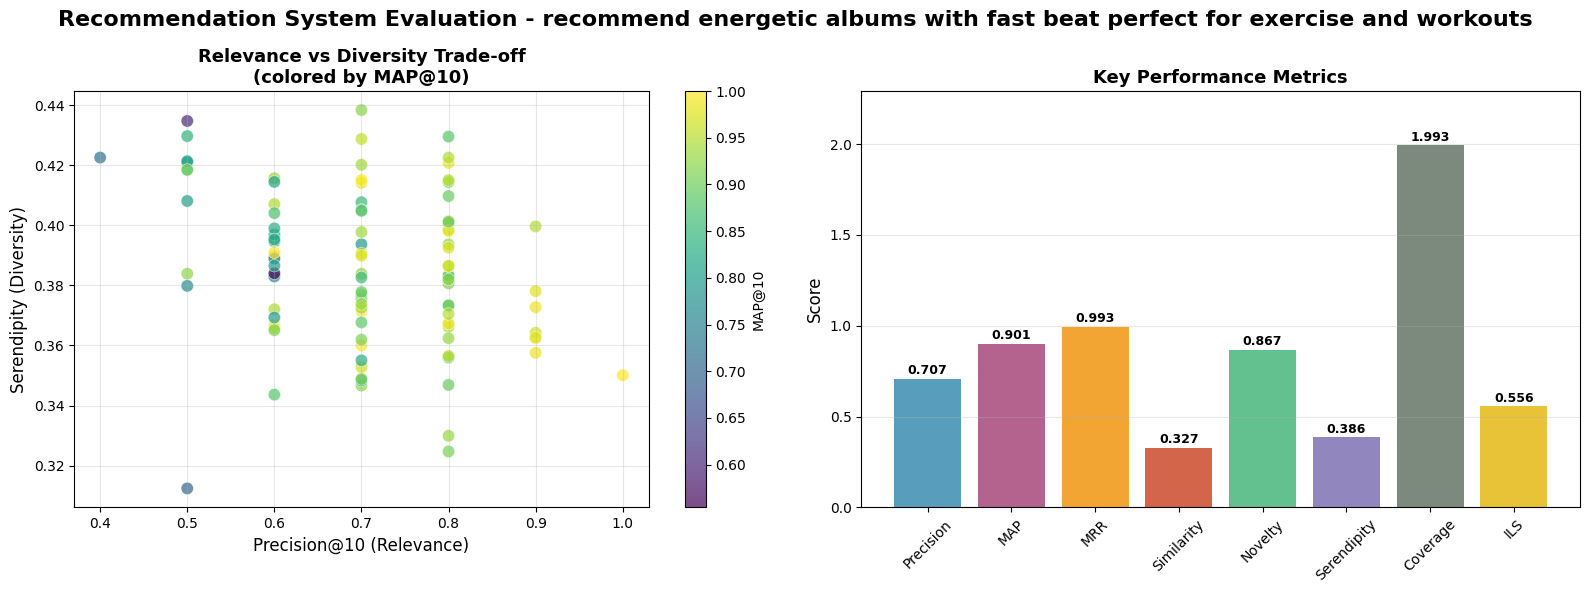

NameError: name 'print_summary_statistics' is not defined

In [21]:
if __name__ == "__main__":
    train_data_path = "train_set.csv"  
    test_data_path = "test_set.csv"   
    
    train_data = pd.read_csv(train_data_path)
    test_data = pd.read_csv(test_data_path)
    print(f"Data loaded:")
    print(f"- Train: {train_data.shape[0]} rows, {train_data['uid'].nunique()} users")
    print(f"- Test:  {test_data.shape[0]} rows, {test_data['uid'].nunique()} users")
    
    # Check if pipeline is saved
    if not is_pipeline_saved():
        print("No saved pipeline found. Please run train_pipeline.py first.")
        exit(1)I
    
    # Choose evaluation mode
    print("EVALUATION MODE")
    print("=" * 40)
    print("1. Quick evaluation")
    print("2. Full evaluation (all users)") 
    print("3. Test different queries/scenarios")
    
    choice = input("\nChoose option (1-3): ").strip()
    
    if choice == "1":
        test_query = input("Enter test query (or press enter for default 'Recommend pop songs or albums with piano-driven melodies'): ").strip()
        if not test_query:
            test_query = "Recommend pop songs or albums with piano-driven melodies"
        print(f"\nRunning quick evaluation with query: '{test_query}'")
        quick_eval(train_data, test_data, test_query=test_query, user_sample=100, save_plots=True, comprehensive_plots=True)
        
    elif choice == "2":
        test_query = input("Enter test query (or press enter for default 'Recommend pop songs or albums with piano-driven melodies'): ").strip()
        if not test_query:
            test_query = "Recommend pop songs or albums with piano-driven melodies"
        print(f"\nRunning full evaluation with query: '{test_query}'")
        full_eval(train_data, test_data, test_query=test_query)
        
    elif choice == "3":
        print("\nTesting different query scenarios...")
        test_comprehensive_scenarios(train_data, test_data)
        
    else:
        print("Invalid choice. Running quick evaluation...")
        quick_eval(train_data, test_data, user_sample=5)

In [22]:
import pandas as pd
import ast

def load_and_print_recommendations(filename=None, query=None):
    """
    Load and print all recommendations from saved file
    
    Args:
        filename (str): Specific filename to load
        query (str): Query to construct filename if not provided
    """
    # Determine filename
    if filename is None:
        if query is None:
            query = "pop music with piano"  # default query
        filename = f"recommendations_{query.replace(' ', '_')}.csv"
    
    try:
        # Load the CSV file
        df = pd.read_csv(filename)
        print(f"Loaded recommendations from: {filename}")
        print(f"Total users: {len(df)}")
        print("=" * 80)
        
        # Print all users and their recommendations
        for idx, row in df.iterrows():
            print(f"\nUSER {idx + 1}: {row['user_id']}")
            print(f"Query: '{row['query']}'")
            print(f"Number of recommendations: {row['recommendation_count']}")
            print("-" * 60)
            
            # Parse recommendations
            try:
                if isinstance(row['recommendations'], str):
                    recommendations = ast.literal_eval(row['recommendations'])
                else:
                    recommendations = row['recommendations']
                
                # Print each recommendation
                for i, rec in enumerate(recommendations, 1):
                    print(f"{i}. Title: {rec.get('title', 'No title')}")
                    print(f"   ID: {rec.get('iid', 'No ID')}")
                    print(f"   Categories: {rec.get('categories', [])}")
                    desc = rec.get('description', '')
                    if desc and desc != 'No description':
                        print(f"   Description: {desc}")
                    print()
                    
            except Exception as e:
                print(f"   Error parsing recommendations: {e}")
                continue
                
        print("=" * 80)
        print(f"Finished printing all {len(df)} users")
        
    except FileNotFoundError:
        print(f"File not found: {filename}")
    except Exception as e:
        print(f"Error loading file: {e}")

load_and_print_recommendations(filename="20251120_081243_recommend_energetic_albums_with_fast_bea_recommendations.csv")

Loaded recommendations from: 20251120_081243_recommend_energetic_albums_with_fast_bea_recommendations.csv
Total users: 100

USER 1: AG2UINGMVGWZPCMCUD3JDHJK7YAQ
Query: 'recommend energetic albums with fast beat perfect for exercise and workouts'
Number of recommendations: 10
------------------------------------------------------------
   Error parsing recommendations: 'recommendations'

USER 2: AHJ5RPKH2V4HYXDERZW332CV2UOA
Query: 'recommend energetic albums with fast beat perfect for exercise and workouts'
Number of recommendations: 10
------------------------------------------------------------
   Error parsing recommendations: 'recommendations'

USER 3: AFBCVQBEOT4PO2JHKMYZLB5DNF5Q
Query: 'recommend energetic albums with fast beat perfect for exercise and workouts'
Number of recommendations: 10
------------------------------------------------------------
   Error parsing recommendations: 'recommendations'

USER 4: AGKOEIMS65JRW3IFWIHRZHSC4GNA
Query: 'recommend energetic albums with f

In [24]:
def evaluate_with_saved_pipeline_debug(train_data, test_data, test_query="", sample_size=None, quick_mode=False, visualize=True, save_prefix=None):
    print("EVALUATION WITH DEBUGGING")
    print("=" * 50)
    
    # Load saved pipeline
    pipeline_objects = load_trained_pipeline_simple()
    if pipeline_objects is None:
        print("No saved pipeline found. Please run train_pipeline.py first.")
        return
    
    # Get qualified test users
    qualified_users = get_qualified_users(train_data, test_data)
    
    if sample_size and sample_size < len(qualified_users):
        qualified_users = qualified_users[:sample_size]
    
    all_relevance_metrics = []
    all_diversity_metrics = []
    successful_evaluations = 0
    
    for i, user_id in enumerate(qualified_users[:3]):  # Only test 3 users for debugging
        print(f"\n=== DEBUGGING USER {i+1}: {user_id} ===")
        
        try:
            # Get recommendations
            recommendations = get_recommendations_for_user(
                pipeline_objects, user_id, test_query, debug=True  # Enable debug
            )
            
            if not recommendations:
                print("No recommendations generated")
                continue
            
            # DEBUG: Check what we're passing to evaluate_query_relevance
            debug_query_relevance(recommendations, test_query, pipeline_objects)
            
            # Calculate relevance metrics
            print("Calling evaluate_query_relevance...")
            relevance_metrics = evaluate_query_relevance(recommendations, test_query, pipeline_objects)
            
            print("Relevance metrics returned:")
            for key, value in relevance_metrics.items():
                if 'score' in key.lower() or 'precision' in key.lower() or 'similarity' in key.lower():
                    print(f"  {key}: {value}")
            
            # Check if metrics are all zeros
            if all(v == 0 for k, v in relevance_metrics.items() if isinstance(v, (int, float))):
                print("WARNING: All relevance metrics are zero!")
            
            # Store results
            relevance_metrics['user_id'] = user_id
            all_relevance_metrics.append(relevance_metrics)
            successful_evaluations += 1
            
        except Exception as e:
            print(f"Error evaluating user {user_id}: {e}")
            import traceback
            traceback.print_exc()
    
    return all_relevance_metrics

In [ ]:
# def calculate_aggregate_diversity_metrics(all_diversity_metrics):
#     """
#     Calculate aggregate diversity metrics across all users
#     """
#     if not all_diversity_metrics:
#         return {}
    
#     df = pd.DataFrame(all_diversity_metrics)
    
#     return {
#         'Mean_CategoryCoverage': df['CategoryCoverage'].mean(),
#         'Mean_UniqueCategories': df['UniqueCategories'].mean(),
#         'Mean_Entropy': df['Entropy'].mean(),
#         'Mean_GiniIndex': df['GiniIndex'].mean(),
#         'Std_CategoryCoverage': df['CategoryCoverage'].std(),
#         'Std_UniqueCategories': df['UniqueCategories'].std()
#     }

# def calculate_aggregate_query_relevance_metrics(user_metrics_list, k=10):
#     """
#     Calculate aggregate metrics for query-based relevance
#     """
#     if not user_metrics_list:
#         return {}

#     df = pd.DataFrame(user_metrics_list)
    
#     # Handle case where column names might vary
#     precision_col = f'Precision@{k}'
#     hitrate_col = f'HitRate@{k}'
    
#     aggregate_metrics = {
#         f'Mean_Precision@{k}': df[precision_col].mean() if precision_col in df.columns else 0,
#         f'Mean_HitRate@{k}': df[hitrate_col].mean() if hitrate_col in df.columns else 0,
#         'Mean_Similarity': df['avg_similarity'].mean() if 'avg_similarity' in df.columns else 0,
#         'Total_Users': len(df)
#     }
    
#     return aggregate_metrics

In [77]:
# evaluate_pipeline.py
import pandas as pd
# from src.evaluation.relevance_metrics import calculate_user_relevance_metrics
from src.evaluation.diversity_metrics import calculate_diversity_metrics, clean_categories
# from src.evaluation.aggregate_metrics import (
#     calculate_aggregate_relevance_metrics, 
#     calculate_aggregate_diversity_metrics
# )

# def evaluate_with_saved_pipeline(test_query="pop music with piano", sample_size=None, quick_mode=False):
#     print("EVALUATION WITH SAVED PIPELINE")
#     print("=" * 50)
    
#     # Load data
#     train_data = pd.read_csv("train_set.csv")
#     test_data = pd.read_csv("test_set.csv")
    
#     print(f"Data loaded:")
#     print(f"- Train: {train_data.shape[0]} rows, {train_data['uid'].nunique()} users")
#     print(f"- Test:  {test_data.shape[0]} rows, {test_data['uid'].nunique()} users")
    
#     # Load saved pipeline
#     pipeline_objects = load_trained_pipeline_simple()
#     if pipeline_objects is None:
#         print("No saved pipeline found. Please run train_pipeline.py first.")
#         return
    
#     # Get qualified test users (users that exist in both train and test)
#     qualified_users = get_qualified_users(train_data, test_data)

#     if sample_size and sample_size < len(qualified_users):
#         qualified_users = qualified_users[:sample_size]
#         print(f"Evaluating {len(qualified_users)} sampled users...")
#     else:
#         print(f"Evaluating all {len(qualified_users)} qualified users...")
    
#     # Store metrics
#     all_relevance_metrics = []
#     all_diversity_metrics = []
#     successful_evaluations = 0
    
#     for i, user_id in enumerate(qualified_users):
#         if quick_mode:
#             print(f"{i+1:3d}/{len(qualified_users)}: {user_id}", end=" ")
#         else:
#             print(f"User {i+1:4d}/{len(qualified_users)}: {user_id}")
        
#         try:
#             # Get recommendations from saved pipeline
#             recommendations = get_recommendations_for_user(
#                 pipeline_objects, user_id, test_query, debug=False
#             )
            
#             if not recommendations:
#                 if quick_mode:
#                     print("→ No recs")
#                 else:
#                     print(f"    → No recommendations")
#                 continue
            
#             # Get ground truth from test data
#             true_items = test_data[test_data['uid'] == user_id]['iid'].unique().tolist()
            
#             if not true_items:
#                 if quick_mode:
#                     print("→ No truth")
#                 else:
#                     print(f"    → No ground truth")
#                 continue
            
#             # Calculate metrics
#             relevance_metrics = calculate_relevance_metrics(true_items, recommendations)
#             diversity_metrics = calculate_diversity_metrics(recommendations)
            
#             # Store results
#             relevance_metrics['user_id'] = user_id
#             diversity_metrics['user_id'] = user_id
            
#             all_relevance_metrics.append(relevance_metrics)
#             all_diversity_metrics.append(diversity_metrics)
#             successful_evaluations += 1
            
#             if quick_mode:
#                 print(f"(HitRate@10: {relevance_metrics['HitRate@10']}, AP@10: {relevance_metrics['AP@10']:.3f}, NDCG@10: {relevance_metrics['NDCG@10']:.3f}, MRR@10: {relevance_metrics['MRR@10']:.3f})")
#             else:
#                 print(f"HitRate@10: {relevance_metrics['HitRate@10']}")
#                 print(f"AP@10: {relevance_metrics['AP@10']:.3f}")
#                 print(f"NDCG@10: {relevance_metrics['NDCG@10']:.3f}")
#                 print(f"MRR@10: {relevance_metrics['MRR@10']:.3f}")
           
#         except Exception as e:
#             if quick_mode:
#                 print(f"Error")
#             else:
#                 print(f"Error: {str(e)[:50]}...")
    
#     # Calculate aggregate results
#     print("\n" + "=" * 50)
#     print("FINAL RESULTS")
#     print("=" * 50)
    
#     if successful_evaluations > 0:
#         aggregate_relevance = calculate_aggregate_relevance_metrics(all_relevance_metrics)
#         aggregate_diversity = calculate_aggregate_diversity_metrics(all_diversity_metrics)
        
#         print(f"\nRELEVANCE METRICS ({successful_evaluations} users):")
#         print(f"   MAP@10:          {aggregate_relevance['MAP@10']:.4f}")
#         print(f"   Mean NDCG@10:    {aggregate_relevance['Mean_NDCG@10']:.4f}")
#         print(f"   Mean Precision@10: {aggregate_relevance['Mean_Precision@10']:.4f}")  # Added
#         print(f"   Mean Recall@10:   {aggregate_relevance['Mean_Recall@10']:.4f}")      # Added
#         print(f"   Mean MRR@10:      {aggregate_relevance['Mean_MRR@10']:.4f}")
#         print(f"   Hit Rate@10:      {aggregate_relevance['HitRate@10']:.4f}")
        
#         print(f"\nDIVERSITY METRICS:")
#         print(f"   Mean Category Coverage: {aggregate_diversity['Mean_CategoryCoverage']:.4f}")
#         print(f"   Mean Unique Categories: {aggregate_diversity['Mean_UniqueCategories']:.2f}")
#         print(f"   Mean Entropy:          {aggregate_diversity['Mean_Entropy']:.4f}")
#         print(f"   Mean Gini Index:       {aggregate_diversity['Mean_GiniIndex']:.4f}")
        
#         # Save results
#         save_evaluation_results(all_relevance_metrics, all_diversity_metrics)
        
#         print(f"\nEvaluation completed!")
#         print(f"Successfully evaluated {successful_evaluations}/{len(qualified_users)} users")
        
#         return aggregate_relevance, aggregate_diversity
        
#     else:
#         print("No successful evaluations!")


# def save_evaluation_results(relevance_metrics, diversity_metrics):
#     rel_df = pd.DataFrame(relevance_metrics)
#     div_df = pd.DataFrame(diversity_metrics).add_prefix('div_')
    
#     results_df = rel_df.merge(div_df, left_on='user_id', right_on='div_user_id')
#     results_df = results_df.drop(['div_user_id'], axis=1)
    
#     results_df.to_csv("evaluation_results.csv", index=False)
#     print(f"Detailed results saved to: evaluation_results.csv")
    
#     # Save summary
#     summary = {
#         'Metric': ['MAP@10', 'Mean_NDCG@10', 'HitRate@10', 
#                   'Mean_CategoryCoverage', 'Mean_UniqueCategories',
#                   'Mean_Entropy', 'Mean_GiniIndex',
#                   'Std_CategoryCoverage', 'Std_UniqueCategories'],
#         'Value': [
#             rel_df['AP@10'].mean(),
#             rel_df['NDCG@10'].mean(),
#             rel_df['HitRate@10'].mean(),
#             div_df['div_CategoryCoverage'].mean(),
#             div_df['div_UniqueCategories'].mean(),
#             div_df['div_Entropy'].mean(),
#             div_df['div_GiniIndex'].mean(),
#             div_df['div_CategoryCoverage'].std(),
#             div_df['div_UniqueCategories'].std()
#         ]
#     }
#     summary_df = pd.DataFrame(summary)
#     summary_df.to_csv("evaluation_summary.csv", index=False)
#     print(f"Summary saved to: evaluation_summary.csv")


# def test_different_queries():
#     """Test the pipeline with different queries"""
#     queries = [
#         "jazz piano music", 
#         "rock classics",
#         "electronic dance music",
#         "relaxing music"
#     ]
    
#     print("TESTING DIFFERENT QUERIES")
#     print("=" * 50)
    
#     for query in queries:
#         print(f"\nTesting query: '{query}'")
#         quick_eval(test_query=query, user_sample=user_sample)  
